In [115]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
df = pd.DataFrame(X, columns=iris.feature_names)

print(f"Shape: {df.shape}")

Shape: (150, 4)


In [116]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=4)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("Clustering Complete")
print(df['Cluster'].value_counts().sort_index())

Clustering Complete
Cluster
0    55
1    49
2    46
Name: count, dtype: int64


c:\Users\saiya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


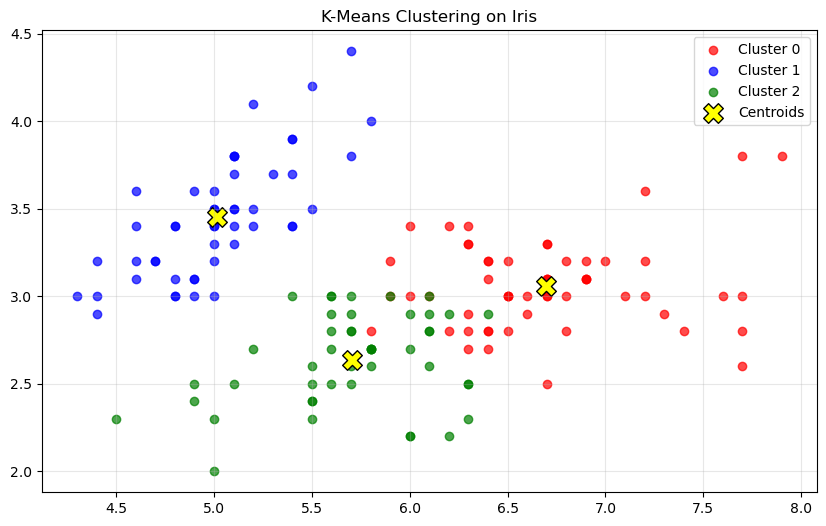

In [117]:
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green']
for i in range(3):
    cluster_points = df[df['Cluster'] == i]
    plt.scatter(cluster_points.iloc[:, 0], cluster_points.iloc[:, 1], 
               c=colors[i], label=f'Cluster {i}', alpha=0.7)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='yellow', marker='X', 
           s=200, edgecolors='black', label='Centroids')

plt.title('K-Means Clustering on Iris')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [118]:
print(f"Inertia: {kmeans.inertia_:.2f}")
for i in range(3):
    print(f"Cluster {i}: {sum(df['Cluster'] == i)} samples")

Inertia: 140.90
Cluster 0: 55 samples
Cluster 1: 49 samples
Cluster 2: 46 samples
